In [1]:
import pickle
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import Divider, Size
from itertools import product
from string import ascii_lowercase
from matplotlib.lines import Line2D

from IPython.display import display, clear_output


In [2]:
# Use .expanduser() to turn "~" into "/home/yourusername"
PICKLED = Path("~/papers/adtxns_paper/pickled_data").expanduser()
SARAFU_PICKLED = PICKLED / "sarafu"

FIGURES = Path("~/papers/adtxns_paper/figures/histograms").expanduser()


In [3]:
sarafu = pickle.load(open(SARAFU_PICKLED / "sarafu.pkl", "rb"))
tx = pickle.load(open(SARAFU_PICKLED / "tx.pkl", "rb"))
users = pickle.load(open(SARAFU_PICKLED / "users.pkl", "rb"))

SINGLE FIGURES

In [ ]:
mpl.rcdefaults()
N=0
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24) 

# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.4, 0.2         # margins in inches
bottom, top = 1.0, 0.2            # margins in inches


fig_w = ax_w + left + right
fig_h = ax_h + bottom + top

In [ ]:
keyword = "inter-event_times"
disp = 'single'
tag = "sarafu-global-vs-single"
x_text = 0.9
y_text = 0.95
xlabel = r"$\tau$"
ylabel = r"$P(\tau)$"

loglog = True


metric= f"inter_event_times"
spec1 = 'individual'
spec2 = 'global'
fname1 = f"sarafu__metric={metric}_{spec1}__s=NA__b=NA.pkl"
fname2 = f"sarafu__metric={metric}_{spec2}__s=NA__b=NA.pkl"

hs = pickle.load(open(SARAFU_PICKLED / "histograms" / fname1, "rb"))
h0 = pickle.load(open(SARAFU_PICKLED / "histograms" / fname2, "rb"))


# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.4, 0.2         # margins in inches
bottom, top = 1.0, 0.2            # margins in inches


fig_w = ax_w + left + right
fig_h = ax_h + bottom + top

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)
ax.plot(h0[0], h0[1], "--", color="k",lw = 5,label = "Global")

most_active_sarafu = sarafu['agents'].nlargest(50, columns = 'tx_out')[['crid','tx_out']]

for k in most_active_sarafu.head(20).crid:
    h = hs[k]
    ax.plot(h[0],h[1])


ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

ax.legend()
# ax.text(0.05,0.1, "(b)", transform=ax.transAxes, va="top")


# optional save (encodes the filter used + metric)
# print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
fig.savefig(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")


PAIRS OF FIGURES

In [17]:
mpl.rcdefaults()
N=10
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24) 


# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.4, 0.2         # margins in inches
bottom, top = 1.0, 0.2            # margins in inches


fig_w = ax_w + left + right
fig_h = ax_h + bottom + top

In [8]:
keyword = "activity_over_time"
disp = 'single'
tag = "sarafu-global-vs-single"
x_text = 0.9
y_text = 0.95
xlabel = r"$n_{out}$"
ylabel = r"$P(n_{out})$"

save_name = f"{disp}__metric={keyword}__filter={tag}.pdf"

loglog = True


hs = pickle.load(open(SARAFU_PICKLED / "histograms" / "sarafu__metric=activity_over_time__s=NA__b=NA.pkl", "rb"))

h0 = hs['global']

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)
ax.plot(h0[0], h0[1], "--", color="k",lw = 5,label = "Global")

periods = [i for i in hs.keys() if i != 'global']
for k in periods:
    h = hs[k]
    ax.plot(h[0],h[1])


ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

ax.legend()
ax.text(0.05,0.1, "(a)", transform=ax.transAxes, va="top")


# optional save (encodes the filter used + metric)
# print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
fig.savefig(FIGURES / f"{save_name}")

plt.close()


In [48]:
keyword = "attractiveness_over_time"
disp = 'single'
tag = "sarafu-global-vs-single"
x_text = 0.9
y_text = 0.95
xlabel = r"$n_{in}$"
ylabel = r"$P(n_{in})$"

save_name = f"{disp}__metric={keyword}__filter={tag}.pdf"

loglog = True


hs = pickle.load(open(SARAFU_PICKLED / "histograms" / f"sarafu__metric={keyword}__s=NA__b=NA.pkl", "rb"))

h0 = hs['global']

fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)
ax.plot(h0[0], h0[1], "--", color="k",lw = 5,label = "Global")

periods = [i for i in hs.keys() if i != 'global']
for k in periods:
    h = hs[k]
    ax.plot(h[0],h[1])


ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

# ax.legend()
ax.text(0.05,0.1, "(b)", transform=ax.transAxes, va="top")


# optional save (encodes the filter used + metric)
# print(FIGURES / f"{disp}__metric={keyword}__filter={tag}.pdf")
fig.savefig(FIGURES / f"{save_name}")
plt.close()


In [11]:
from local_utils import compute_js_distance

In [31]:
NUM_PERIODS = 20
# TXDF =pickle.load(open(SARAFU_PICKLED/"tx.pkl","rb"))
# tx = TXDF.copy(deep=True)
tx = sarafu['transactions']
tx['period'] = pd.cut(tx.index, NUM_PERIODS, labels=False) #periodize by constant activity
agents = sarafu['agents']


In [32]:
data = []
for period,group in tx.groupby('period'):
    data.append(pd.Series(group.groupby('source').weight.count().values))

js_test_activity_glob = []
js_test_activity_seq = []


for i in range(1,len(data)):
    # data = data/s
    js_test_activity_seq.append(compute_js_distance((data[i]),(data[i-1]))[1])

for i in range(len(data)):
    js_test_activity_glob.append(compute_js_distance((data[i]),(agents.tx_out))[1])

/tmp/ipykernel_3763/4002838241.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


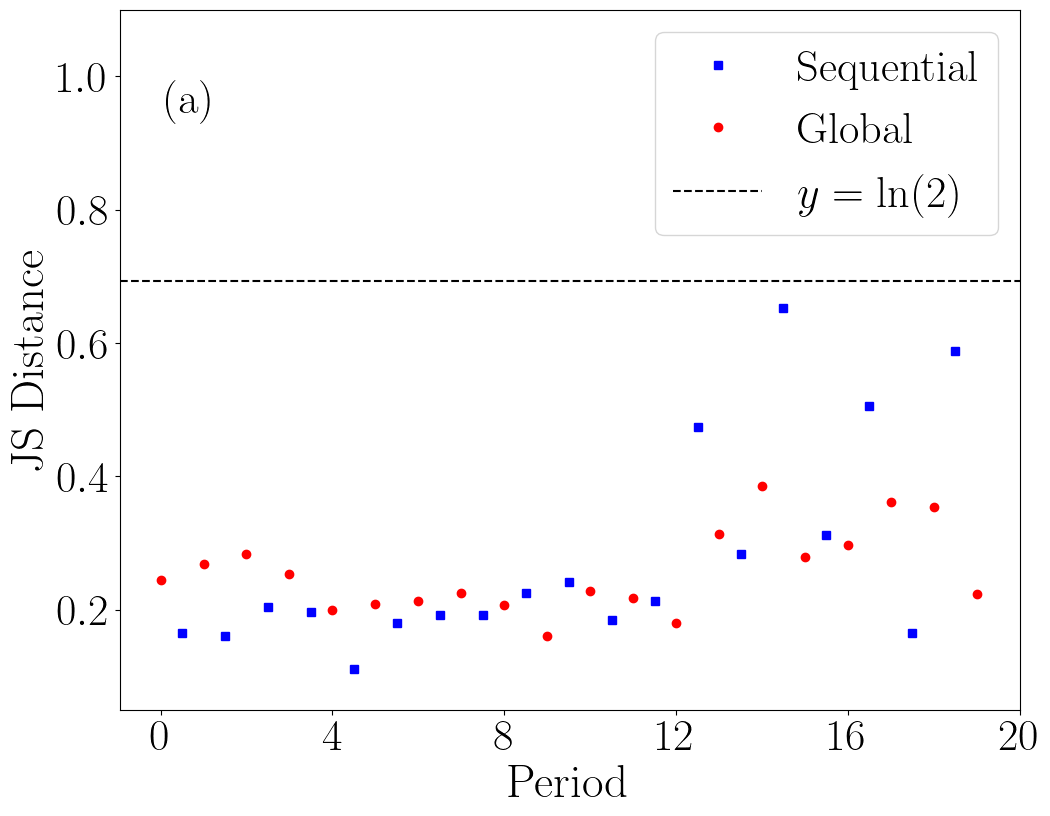

In [46]:
keyword = "activity_jstest"
disp = 'single'
tag = "sarafu-global-vs-single"
x_text = 0.9
y_text = 0.95
xlabel = r"Period"
ylabel = r"JS Distance"

save_name = f"{disp}__metric={keyword}__filter={tag}.pdf"

loglog = False



fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)


ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

ax.legend()
ax.text(0.05,0.9, "(a)", transform=ax.transAxes, va="top")

ax.plot(np.arange(0.5, len(js_test_activity_seq) + 0.5, 1), js_test_activity_seq, 'bs', label='Sequential ')
ax.plot(np.arange(0, len(js_test_activity_glob), 1), js_test_activity_glob, 'ro', label='Global ')
# Add threshold line
ax.axhline(y=np.log(2), label='$y=\ln(2)$', color='k', linestyle='--')

# Set integer ticks
ax.set_xticks(np.arange(0, len(js_test_activity_glob) + 1,4))  # Ensure only integers are shown

ax.set_ylim(0.05,1.1)


ax.legend()

# Show plot
# plt.show()
fig.savefig(FIGURES / f"{save_name}")


In [34]:
data = []
for period,group in tx.groupby('period'):
    data.append(pd.Series(group.groupby('target').weight.count().values))

js_test_attractiveness_glob = []
js_test_attractiveness_seq = []

for i in range(1,len(data)):
    # data = data/s
    js_test_attractiveness_seq.append(compute_js_distance((data[i]),(data[i-1]))[1])

for i in range(len(data)):
    js_test_attractiveness_glob.append(compute_js_distance((data[i]),(agents.tx_in))[1])

In [1]:
keyword = "attractiveness_jstest"
disp = 'single'
tag = "sarafu-global-vs-single"
x_text = 0.9
y_text = 0.95
xlabel = r"Period"
ylabel = r"JS Distance"

save_name = f"{disp}__metric={keyword}__filter={tag}.pdf"

loglog = False



fig = plt.figure(figsize=(fig_w, fig_h))

divider = Divider(
    fig, (0, 0, 1, 1),
    horizontal=[
        Size.Fixed(left),
        Size.Fixed(ax_w),
        Size.Fixed(right),
    ],
    vertical=[
        Size.Fixed(bottom),
        Size.Fixed(ax_h),
        Size.Fixed(top),
    ],
)

ax = fig.add_axes(
    divider.get_position(),
    axes_locator=divider.new_locator(nx=1, ny=1)
)


ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
if loglog:
    ax.loglog()

ax.legend()
ax.text(0.05,0.9, "(b)", transform=ax.transAxes, va="top")

ax.plot(np.arange(0.5, len(js_test_attractiveness_seq) + 0.5, 1), js_test_attractiveness_seq, 'bs', label='Sequential ')
ax.plot(np.arange(0, len(js_test_attractiveness_glob), 1), js_test_attractiveness_glob, 'ro', label='Global ')
# Add threshold line
ax.axhline(y=np.log(2), label='Threshold', color='k', linestyle='--')

# Set integer ticks
ax.set_xticks(np.arange(0, len(js_test_activity_glob) + 1,4))  # Ensure only integers are shown

ax.set_ylim(0.05,1.1)
# ax.legend()

# Show plot
# plt.show()
fig.savefig(FIGURES / f"{save_name}")


NameError: name 'plt' is not defined

In [52]:
#* UNFILTERED DATA 
TXDF = pickle.load(open(SARAFU_PICKLED / f"tx.pkl", "rb"))
USERS = pickle.load(open(SARAFU_PICKLED / f"users.pkl", "rb"))

END = pd.to_datetime(TXDF.date.max())
START = pd.to_datetime(TXDF.date.min())
NUM_PERIODS = 20
BAD_USERS = [8356,8357,21712,54998]



#TRANSACTIONS DF FILTERS
standard_tx = lambda tx: tx.type == 'STANDARD'
good_users = lambda tx: ~tx.source.isin(BAD_USERS) | ~tx.target.isin(BAD_USERS)
std_roles = lambda tx: tx.source_role.isin(['BENEFICIARY','GROUP_ACCOUNT','VENDOR']) | tx.target_role.isin(['BENEFICIARY','GROUP_ACCOUNT','VENDOR'])   
standard = lambda tx: standard_tx(tx) & good_users(tx) & std_roles(tx)

disbursement = lambda tx: tx.type == 'DISBURSEMENT'
withdrawal = lambda tx: tx.type.isin(['RECLAMATION','AGENT_OUT'])

from_kinango = lambda tx: tx.source_area == 'Kinango Kwale'
to_kinango = lambda tx: tx.target_area == 'Kinango Kwale'
just_kinango = lambda tx: from_kinango(tx) & to_kinango(tx) 

from_mukuru = lambda tx: tx.source_area == 'Mukuru Nairobi'
to_mukuru = lambda tx: tx.target_area == 'Mukuru Nairobi'
just_mukuru = lambda tx: from_mukuru(tx) & to_mukuru(tx) 


#BalanceS DFS FILTERS
balxmin = lambda bal,feat,tau: bal[feat]>=tau
balxinf = lambda bal,feat,tau: bal[feat]>tau
balxmax = lambda bal,feat,tau: bal[feat]<=tau
balxsup = lambda bal,feat,tau: bal[feat]<tau

#AGENTS DFS FILTERS
agxmin = lambda ag,feat,tau: ag[feat]>=tau
agxinf = lambda ag,feat,tau: ag[feat]>tau
agxmax = lambda ag,feat,tau: ag[feat]<=tau
agxsup = lambda ag,feat,tau: ag[feat]<tau


In [53]:
def balance_constructor(tx_with_bal, users, bins = 20, index = None):

    if 'period' not in tx_with_bal.columns:
        print('Adding period column to txns dataframe...')
        if index is None:
            tx_with_bal['period'] = pd.cut(tx_with_bal.index, bins=bins,labels=False)
        if index is not None:
            tx_with_bal['period'] = pd.cut(tx_with_bal[index], bins=bins,labels=False)
    else: 
        print('period already in txns dataframe')

    balances_pre = pd.DataFrame({
        'id': tx_with_bal['id'].repeat(2).values,
        'date': tx_with_bal['date'].repeat(2).values,  # Repeat each time twice
        'balance': tx_with_bal[['source_bal_pre', 'target_bal_pre']].values.flatten(),
        'xdai': tx_with_bal[['source_xdai', 'target_xdai']].values.flatten(),  # Stack feature1 and feature2 in an alternating pattern
        'type': tx_with_bal['type'].repeat(2).values,
        'period':tx_with_bal['period'].repeat(2).values,
        'weight': tx_with_bal['weight'].repeat(2) * np.tile([-1,1],len(tx_with_bal)),
        'kind': np.tile(['source','target'],len(tx_with_bal))
    })

    balances_post = pd.DataFrame({
        'id': tx_with_bal['id'].repeat(2).values,
        'date': tx_with_bal['date'].repeat(2).values,  # Repeat each time twice
        'balance': tx_with_bal[['source_bal_post', 'target_bal_post']].values.flatten(),
        'xdai': tx_with_bal[['source_xdai', 'target_xdai']].values.flatten(),  # Stack feature1 and feature2 in an alternating pattern
        'type': tx_with_bal['type'].repeat(2).values,
        'period':tx_with_bal['period'].repeat(2).values,
        'weight': tx_with_bal['weight'].repeat(2) * np.tile([-1,1],len(tx_with_bal)),
        'kind': np.tile(['source','target'],len(tx_with_bal))
    })

    balances_pre.balance = balances_pre.balance.apply(lambda x: 0 if abs(x) < 1e-3 else x)
    balances_post.balance = balances_post.balance.apply(lambda x: 0 if abs(x) < 1e-3 else x)
    
    balances_pre = balances_pre.merge(
        users[['xdai', 'role', 'area_type', 'area_name','svol_in', 'svol_out','stxns_in', 'stxns_out', 'sunique_in', 'sunique_out','initial_bal','final_bal','net','otxns_in', 'otxns_out','crid']],  # Ensure the right columns are selected
        on='xdai',  # Use 'xdai' as the merge key in users
        how='left'
    )
    balances_post = balances_post.merge(
        users[['xdai', 'role', 'area_type', 'area_name','svol_in', 'svol_out','stxns_in', 'stxns_out', 'sunique_in', 'sunique_out','initial_bal','final_bal','net','otxns_in', 'otxns_out','crid']],  # Ensure the right columns are selected
        on='xdai',  # Use 'xdai' as the merge key in users
        how='left'
    )

    return balances_pre, balances_post

def scale_vect(arr):
    return (arr-min(arr))/(max(arr)-min(arr))

In [ ]:
txns_floor = 0
bal_floor = 0

txdf = TXDF.copy(deep=True) #always do this
txdf['period'] = pd.cut(txdf.date, bins=NUM_PERIODS, labels=False) 


disb_df = txdf[disbursement(txdf)]
out_df = txdf[withdrawal(txdf)]
std_df = txdf[standard(txdf)]

bal_pre, bal_post = balance_constructor(txdf,USERS)
bal_df = bal_post.loc[(~bal_post.role.isin(['ADMIN','TOKEN_AGENT']))]
bal_pivot = pd.pivot_table(bal_df, index='crid',columns='period', values='balance', aggfunc='last')
bal_pivot = bal_pivot.ffill(axis=1)
# bal_pivot = sarafu['balance_pivot']

disb_list = [disb_df.loc[txdf.period==i]['weight'] for i in disb_df['period'].unique()]
out_list = [out_df.loc[txdf.period==i]['weight'] for i in out_df['period'].unique()]
std_list = [std_df.loc[txdf.period==i]['weight'] for i in std_df['period'].unique()]

bal_list = [bal_pivot[col].values for col in bal_pivot.columns]



disb_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in disb_list])
out_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in out_list])
std_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in std_list])
bal_sum = np.array([np.sum(np.where(~np.isnan(sample),sample,0)) for sample in bal_list])
bal_sum_0 = bal_pre.loc[(~bal_pre.role.isin(['ADMIN','TOKEN_AGENT']))].groupby('crid').balance.first().sum()
net = bal_sum_0 + disb_sum - out_sum 
population = bal_pivot.count()
total_activity = std_df.groupby('period').weight.count()
calc_bal_sum = disb_sum - out_sum

period_to_date = txdf.groupby('period')['date'].min()  # Get start date for each period
dates = period_to_date.sort_index().values  # Ensure chronological order



period already in txns dataframe


: 

In [ ]:
mpl.rcdefaults()
N=10
#* BIGGER SIZE
plt.rcParams.update({"text.usetex": True})
plt.rcParams["font.family"] = 'STIXGeneral'
plt.rc('font', size=N+22)          # controls default text sizes
plt.rc('axes', titlesize=N+24)     # fontsize of the axes title
plt.rc('axes', labelsize=N+24)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('ytick', labelsize=N+22)    # fontsize of the tick labels
plt.rc('legend', fontsize=N+22)    # legend fontsize
plt.rc('figure', titlesize=N+24) 


# --------------------------------------------------
# FIXED AXES GEOMETRY (edit numbers if needed)
# --------------------------------------------------
ax_w, ax_h = 9, 7                 # axes size in inches
left, right = 1.4, 0.2         # margins in inches
bottom, top = 1.0, 0.2            # margins in inches


fig_w = ax_w + left + right
fig_h = ax_h + bottom + top
# -----------------------
# first plot: flows
# -----------------------
# fig,ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.0, 1.0, 0.7, 0.3))
fig, ax = fixed_axes(ax_w=9, ax_h=7, margins=(1.2, 1.2, 1.2, 0.6))

# fig = plt.figure(figsize=(W, H))
# ax = fig.add_axes([L, B, WW, HH])

ax.plot(dates, disb_sum, label='Total Disbursement')
ax.plot(dates, -out_sum, label='Total Reclamation')
ax.plot(dates, std_sum, label='Total Standard')
ax.plot(dates, net, label='Net Balance')
ax.plot(dates, bal_sum, '-.', label='Total Wealth')

ax.axhline(y=0, color='k', linestyle='--')
ax.axhline(y=bal_sum_0, color='k', linestyle='--')

ax.tick_params(axis='x', rotation=45)
ax.set_ylabel("Sarafu")
ax.legend(prop={"size": 18})

fig.savefig(FIGURES / "flows.pdf", format="pdf",bbox_inches=None, pad_inches =0.0 )
# plt.close(fig)